In [1]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=3)
pd.set_option("display.precision", 3)

df = pd.read_csv("data/health_study_dataset.csv")

display(df.describe())
display(df.info())
display(df.head(3))

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,400.500,49.426,171.849,73.413,149.179,4.929,0.059
std,231.084,14.501,9.804,13.685,12.793,0.848,0.235
min,1.000,18.000,144.400,33.700,106.800,2.500,0.000
25%,200.750,39.000,164.775,64.800,140.900,4.328,0.000
50%,400.500,50.000,171.350,73.200,149.400,4.970,0.000
75%,600.250,59.000,178.925,82.600,157.600,5.482,0.000
max,800.000,90.000,200.400,114.400,185.900,7.880,1.000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0


### Beskrivande analys
Räkna ut för: age, weight, height, systolic_bp, cholesterol.
- Medel
- Median
- Min 
- Max    


In [2]:
cols = ['age', 'weight', 'height', 'systolic_bp', 'cholesterol']

desc_stats = df[cols].agg(['mean', 'median', 'min', 'max'])
print(desc_stats)

           age   weight   height  systolic_bp  cholesterol
mean    49.426   73.413  171.849      149.179        4.929
median  50.000   73.200  171.350      149.400        4.970
min     18.000   33.700  144.400      106.800        2.500
max     90.000  114.400  200.400      185.900        7.880


### Skapa minst 3 olika grafer 
- Histogram över blodtryck
- Boxplot över vikt per kön
- Stapeldiagram över andelen rökare

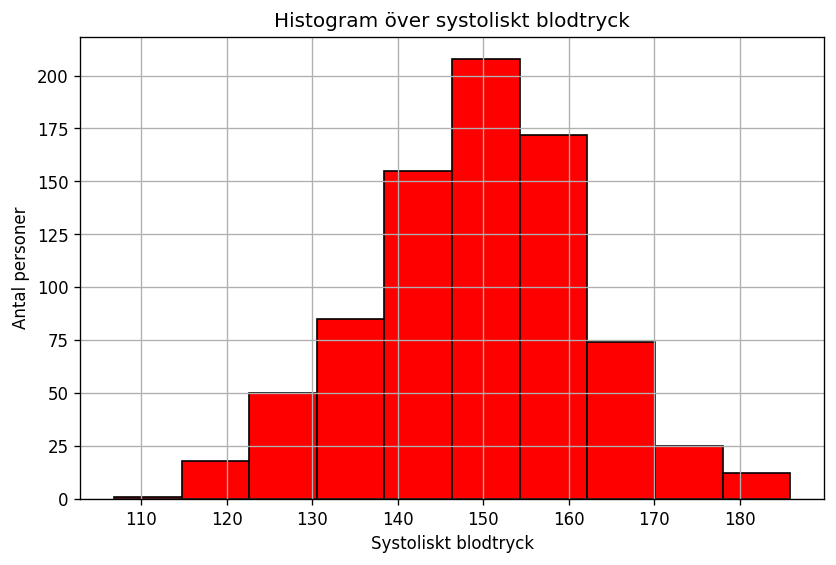

C:\Users\timry\AppData\Local\Temp\ipykernel_61520\2865857273.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_f, data_m], labels=['F', 'M'])


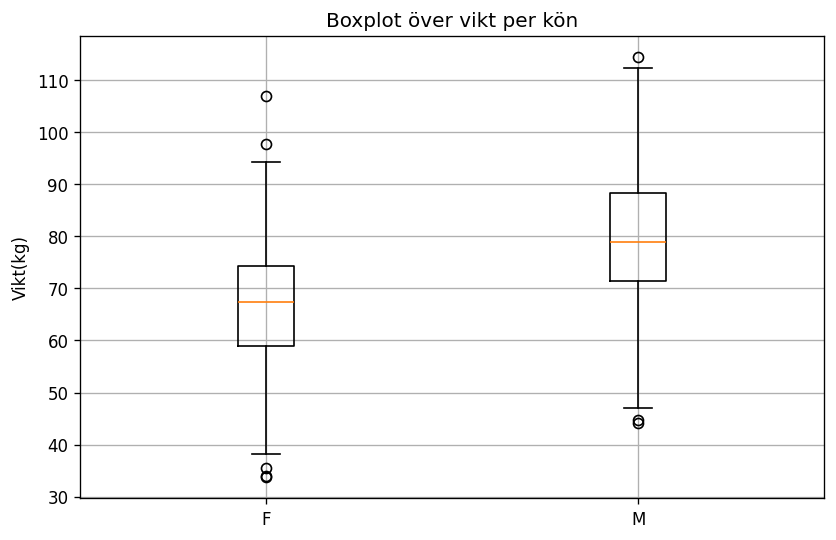

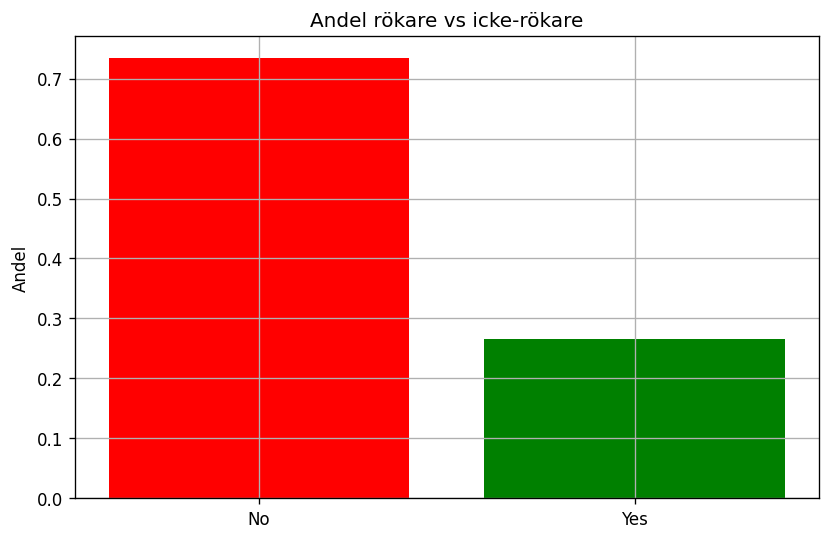

In [3]:
# Histogram över systoliskt blodtryck
fig, ax = plt.subplots()

ax.hist(df['systolic_bp'], bins=10, color='r', edgecolor='black')
ax.set_title("Histogram över systoliskt blodtryck")
ax.set_xlabel("Systoliskt blodtryck")
ax.set_ylabel("Antal personer")
plt.show()

#Boxplot över vikt per kön
fig, ax = plt.subplots()

data_f = df[df['sex']=='F']['weight']
data_m = df[df['sex']=='M']['weight']

ax.boxplot([data_f, data_m], labels=['F', 'M'])
ax.set_title("Boxplot över vikt per kön")
ax.set_ylabel("Vikt(kg)")
plt.show()

# Stapeldiagram över andelen rökare, nornamlize = True för att få andelar
fig, ax = plt.subplots()

smoker_counts = df['smoker'].value_counts(normalize=True)

ax.bar(smoker_counts.index, smoker_counts.values, color=['r','g'])
ax.set_title("Andel rökare vs icke-rökare")
ax.set_ylabel("Andel")
plt.show()

### Simulering kopplad till caset (använd numpy.random + seed)
- Beräkna andelen personer i datasetet som har sjukdomen.
- Använd numpy för att simulera 1000 slumpade personer med samma sannolikhet för sjukdom.
- Jämför den simulerade andelen med den verkliga andelen i datasetet.

In [4]:
np.random.seed(42)

# Andel med sjukdomen i datan
disease_rate = df['disease'].mean()
print(f"Andel med sjukdom: {disease_rate:.3f}")

# Simulera 1000 personer med samma sannolikhet, använder binomial för att det finns två möjliga utfall. Dvs antingen sjuk eller inte.
simulated = np.random.binomial(1, disease_rate, size=1000)
simulated_rate = simulated.mean()
print(f"Simulerad andel: {simulated_rate:.3f}")

Andel med sjukdom: 0.059
Simulerad andel: 0.056


### Konfidensintervall
Beräkna ett konfidensintervall för medelvärdet av systolic_bp (t.ex. med normalapproximation eller bootstrap, som vi gått igenom på kursen).

In [5]:
bp = df['systolic_bp']
n = len(bp)
mean_bp = bp.mean()
std_bp = bp.std(ddof=1)

# Normalapproximation
z = 1.96
margin = z * std_bp / np.sqrt(n)
ci = (mean_bp - margin, mean_bp + margin)
print(f"95% konfidensintervall: {ci}")

95% konfidensintervall: (np.float64(148.29209036025347), np.float64(150.06515963974655))


### Hypotesprövning
- Testa hypotesen: ”Rökare har högre medel-blodtryck än icke-rökare.”
- Använd en av metoderna vi gått igenom (t.ex. bootstrap eller enkel t-test-funktion).
- Förklara kort resultatet i en markdown-ruta.

In [6]:
smokers = df[df['smoker']=='Yes']['systolic_bp']
nonsmokers = df[df['smoker']=='No']['systolic_bp']

# Welch t-test (inte lika varians)
t_stat, p_two_sided = stats.ttest_ind(smokers, nonsmokers, equal_var=False)

# En-sidigt p-värde: rökare > icke-rökare
if t_stat > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - p_two_sided / 2

print(f"t-statistic: {t_stat:.2f}")
print(f"p-värde (one-sided, rökare > icke-rökare): {p_one_sided:.3f}")


t-statistic: 0.45
p-värde (one-sided, rökare > icke-rökare): 0.326


Om p-värdet är mindre än 0.05 kan vi avvisa nollhypotesen och säga att rökare har högre medel-blodtryck. Däremot om p-värdet är större än 0.05 finns det ingen skillnad som är statistiskt säkerställd.

##### Slutsats:

- Vi kan inte förkasta nollhypotesen (H₀).

- Det finns inte tillräcklig statistisk evidens för att säga att rökare har högre medel-blodtryck i detta dataset.

- Det positiva T-värdet indikerar att riktningen av hypotesen är rätt men är såpass låg att man inte kan säga något kring den.

- Skillnaden som observeras kan mycket väl bero på slumpvariation.

### För VG ska du även göra:

- Beräkna konfidensintervallet med två olika metoder (t.ex. normalapproximation och bootstrap) och jämför resultaten.


In [7]:
boot_means = [bp.sample(n, replace=True).mean() for _ in range(1000)]
boot_ci = np.percentile(boot_means, [2.5, 97.5])

print(f"95% konfidensintervall (bootstrap): {boot_ci}")

95% konfidensintervall (bootstrap): [148.316 150.094]


Jämför vi med tidigare räknat konfidensintervall med normalapproximation så blev resultatet väldigt lika.
#### Normalapproximation:
95% konfidensintervall: (np.float64(148.29209036025347), np.float64(150.06515963974655))
#### Bootstrap:
95% konfidensintervall (bootstrap): [148.30950625 150.09898125]

-----


#### Fortsättning VG
-------------------------
- Gör en simulering för att undersöka hur säkert ditt hypotes­test är (t.ex. hur ofta testet hittar en skillnad när den finns → power).
- Motivera dina metodval i markdown och hänvisa till dokumentation eller annan källa.

Nedan räknar jag ut power mha simulering. Jag testar även för olika effects.

In [8]:
n1 = len(smokers)
n2 = len(nonsmokers)
mean_s = smokers.mean()
mean_ns = nonsmokers.mean()
std_s = smokers.std()
std_ns = nonsmokers.std()

effect_values = [2, 3, 5, 8]  # skillnad i medelvärde som vi vill kunna upptäcka/testa för

simulations = 5000
power_simulated = []

for effect in effect_values:
    significant = 0
    for _ in range(simulations):
        sim_s = np.random.normal(mean_s + effect, std_s, n1)
        sim_ns = np.random.normal(mean_ns, std_ns, n2)
        t_stat, p_val = stats.ttest_ind(sim_s, sim_ns, equal_var=False)
        # En-sidigt test
        if p_val/2 < 0.05 and np.mean(sim_s) > np.mean(sim_ns):
            significant += 1
    power_simulated.append(significant / simulations)


for eff, pow_val in zip(effect_values, power_simulated):
    print(f"Effect {eff} mmHg -> Power: {pow_val:.2f}")


Effect 2 mmHg -> Power: 0.77
Effect 3 mmHg -> Power: 0.95
Effect 5 mmHg -> Power: 1.00
Effect 8 mmHg -> Power: 1.00


Räkna ut power mha TTestIndPower, testar för olika effects

In [9]:

pooled_std = np.sqrt((smokers.std()**2 + nonsmokers.std()**2)/2)

analysis = TTestIndPower()
powers = []

for effect in effect_values:
    effect_size = effect / pooled_std  # Cohen's d  
    power = analysis.solve_power(effect_size=effect_size,
                                 nobs1=n1,
                                 ratio=n2/n1,
                                 alpha=0.05,
                                 alternative='larger')  # en-sidigt test
    
  
    
    powers.append(power)  


for eff, pow_val in zip(effect_values, powers):
    print(f"Effect {eff} mmHg -> Power: {pow_val:.2f}")



Effect 2 mmHg -> Power: 0.61
Effect 3 mmHg -> Power: 0.89
Effect 5 mmHg -> Power: 1.00
Effect 8 mmHg -> Power: 1.00


#### Slutsats:

- För att kunna förkasta nollhypotesen med mer än 80% säkerhet så behöver verklig skillnad vara mer än 2 mmHG enligt simuleringen.

- Genom att göra om testet flera gånger så kan man räkan ut den statistiska styrkan av ens test.    
   Källa: https://www.youtube.com/watch?v=Rsc5znwR5FA